# Seeded re-runs of Table 1 and Table 2 (Model A), and a BAT baseline

Three revisions to the paper, in one notebook:

1. **RNG fix + Table 1 re-run.** In Part I, weight initialization and minibatch shuffling draw from the
   *global* NumPy/Torch RNG. That state keeps advancing from cell to cell, so each pool's result depends on
   what ran before it. Here every training run is seeded explicitly (`torch.manual_seed(seed)` and a private
   `RandomState(seed)` for shuffling), and the pool comparison is repeated over `N_SEEDS` seeds. Everything
   else stays as in Part I: the data (20 w × 4 T points per molecule), the hash split (`sha256 % 100 < 15`),
   the fixed interpolation/validation split, the architecture and the optimizer.
2. **Model A seed repeat (Table 2).** Model A is the only Table 2 row without ± sd. It is re-run with Part II's
   exact configuration (10 w × 3 T points per molecule, 300 epochs, patience 25, same hash split), so its
   mean ± sd can be compared directly with the Model B–G rows.
3. **BAT baseline.** Gorkowski, Preston & Zuend (2019, ACP) built the Binary Activity Thermodynamics (BAT)
   model as a reduced-complexity fit to AIOMFAC for binary water–organic systems. It uses only O:C, molar mass
   and density. It is the natural "no training needed" baseline for a feature-based AIOMFAC surrogate, and
   reviewers are likely to ask for it. BAT is evaluated here as implemented in the open-source `particula`
   package, with density from the Girolami method. It is scored on the same held-out molecules and points as
   the surrogate.

Runtime: about 10–15 min on a CPU (Colab or local).

## 0) Setup

In [1]:
try:
    from google.colab import files
    import os
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")

Not running in Colab -- make sure bimog_unified.json is in the current directory.


In [2]:
try:
    import aiomfac_py, rdkit  # noqa: F401
    print("aiomfac_py and rdkit already available")
except ImportError:
    from pathlib import Path
    import subprocess
    REPO_URL = "https://github.com/SeoulTechPSE/aiomfac-python.git"
    REPO_DIR = Path("/content") / "aiomfac-python"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate --smiles")
    subprocess.run(["pip", "install", "-q", "rdkit"], check=True)
try:
    import particula  # noqa: F401
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "particula"], check=True)

aiomfac_py and rdkit already available


In [3]:
import json, time, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger

import aiomfac_py as aiomfac
from aiomfac_py import ActivityModel, Component
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py.params import load_subgroup_params
import aiomfac_py.s2as._mapping as _aiomfac_mapping
import particula
from particula.activity import bat_activity_coefficients
from particula.particles import get_organic_density_array

_aiomfac_mapping.print = lambda *args, **kwargs: None
RDLogger.DisableLog("rdApp.*")
sg = load_subgroup_params()
torch.set_num_threads(max(1, torch.get_num_threads()))

N_SEEDS = 5
SEEDS = tuple(range(N_SEEDS))
print(f"aiomfac_py {aiomfac.__version__} | torch {torch.__version__} | particula {particula.__version__} | "
      f"seeds={SEEDS}")

aiomfac_py 0.0.24 | torch 2.14.1 | particula 0.2.14 | seeds=(0, 1, 2, 3, 4)


## 1) Shared code (Part I functions plus one seeded trainer)

`decompose_pool`, `build_dataset` and `rich_features` are copied from Part I. `decompose_pool` additionally
records H:C (needed for BAT density) and the s2as unmatched-atom count. `train_eval_seeded` reproduces
`train_and_eval` exactly, with two changes: the epoch and patience limits are parameters, and **all**
randomness inside one call comes from `seed`. As in Part I, the interpolation and validation splits are fixed
with `RandomState(0)`, so the seed changes only weight initialization and minibatch order. The spread across
seeds therefore isolates training noise.

In [4]:
def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


def decompose_pool(candidates):
    kept, removed = [], []
    for d in candidates:
        smi = d["smiles"]
        r = smiles_to_components([smi], water_as_component1=True)
        if r.removed:
            removed.append((d["name"], smi, r.removed[0][2]))
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                raise ValueError("non-positive gamma at sanity point")
        except Exception as exc:
            removed.append((d["name"], smi, f"ActivityModel failed: {exc}"))
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            removed.append((d["name"], smi, "RDKit could not parse"))
            continue
        mol_h = Chem.AddHs(mol)
        sym = [a.GetSymbol() for a in mol_h.GetAtoms()]
        n_c, n_o, n_n, n_h = sym.count("C"), sym.count("O"), sym.count("N"), sym.count("H")
        mw = sum(a.GetMass() for a in mol_h.GetAtoms())
        kept.append({"name": d["name"], "smiles": smi, "category": d.get("category", "cho"),
                     "subgroups": organic.subgroups, "molar_mass_g_mol": mw,
                     "o_to_c": n_o / max(n_c, 1), "n_to_c": n_n / max(n_c, 1),
                     "h_to_c": n_h / max(n_c, 1), "n_unmatched": int(r.n_unmatched_atoms[0])})
    return kept, removed


def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        water = Component(1, "Water", ((16, 1),))
        organic = Component(2, o["name"], tuple((s, q) for s, q in o["subgroups"]))
        try:
            m = ActivityModel([water, organic])
        except Exception:
            continue
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        wtf_water = rng.uniform(edges[:-1], edges[1:])
        temps = rng.uniform(273.15, 313.15, n_temp)
        for wtf_w in wtf_water:
            for T in temps:
                try:
                    res = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass")
                    lw, lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
                    if np.isfinite(lw) and np.isfinite(lo):
                        rows.append({"organic_idx": oi, "wtf_water": float(wtf_w), "T_K": float(T),
                                     "ln_gamma_water": lw, "ln_gamma_organic": lo})
                except Exception:
                    continue
    return rows


def rich_features(kept):
    vocab = sorted({int(s) for o in kept for s, q in o["subgroups"]})
    main_groups = sorted({sg.main_group(s) for s in vocab})
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for o in kept:
        mg_counts, total_q = np.zeros(len(main_groups)), 0
        for s, q in o["subgroups"]:
            mg_counts[mg_index[sg.main_group(int(s))]] += q
            total_q += q
        feat.append(np.concatenate([mg_counts / max(total_q, 1),
                                    [o["o_to_c"], o["n_to_c"], np.log(o["molar_mass_g_mol"]), np.log1p(total_q)]]))
    return np.array(feat, dtype=np.float32)


def is_test_molecule(smiles):
    return int(hashlib.sha256(smiles.encode()).hexdigest(), 16) % 100 < 15


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


def to_t(a):
    return torch.tensor(a, dtype=torch.float32)


def train_eval_seeded(rows, feat, test_mols, seed, max_epochs=500, patience=30):
    '''Part I train_and_eval with explicit seeding. Returns dict with interp/gen MAE and per-point gen preds.'''
    organic_idx = np.array([r["organic_idx"] for r in rows])
    X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in rows], dtype=np.float32)
    y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows], dtype=np.float32)
    X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)

    gen_mask = np.isin(organic_idx, list(test_mols))
    train_idx_all = np.where(~gen_mask)[0]
    perm = np.random.RandomState(0).permutation(len(train_idx_all))        # fixed split, as in Part I
    n_interp = int(0.2 * len(train_idx_all))
    interp_idx, fit_idx = train_idx_all[perm[:n_interp]], train_idx_all[perm[n_interp:]]
    gen_idx = np.where(gen_mask)[0]
    n_val = int(0.1 * len(fit_idx))
    val_sel, fit_sel = np.arange(n_val), np.arange(n_val, len(fit_idx))

    x_mean, x_std = X[fit_idx].mean(0), X[fit_idx].std(0) + 1e-6
    y_mean, y_std = y[fit_idx].mean(0), y[fit_idx].std(0) + 1e-6
    Xn, Yn = (X - x_mean) / x_std, (y - y_mean) / y_std
    X_fit_t, Y_fit_t = to_t(Xn[fit_idx]), to_t(Yn[fit_idx])

    torch.manual_seed(seed)                       # <-- RNG fix: init and shuffling both owned by this call
    shuffle_rng = np.random.RandomState(seed)
    model = MLPHead(X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(max_epochs):
        model.train()
        perm_e = shuffle_rng.permutation(fit_sel)
        for s in range(0, len(perm_e), 256):
            idx = perm_e[s:s + 256]
            opt.zero_grad()
            loss_fn(model(X_fit_t[idx]), Y_fit_t[idx]).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(X_fit_t[val_sel]), Y_fit_t[val_sel]).item()
        if vloss < best_val - 1e-5:
            best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(to_t(Xn)).numpy() * y_std + y_mean
    err = np.abs(pred - y)
    return {"interp": err[interp_idx].mean(0), "gen": err[gen_idx].mean(0),
            "gen_idx": gen_idx, "gen_err": err[gen_idx], "organic_idx": organic_idx, "epochs": epoch + 1}


def fmt(vals):
    vals = np.asarray(vals, dtype=float)
    return f"{vals.mean():.3f} ± {vals.std(ddof=1):.3f}" if len(vals) > 1 else f"{vals.mean():.3f}"

In [5]:
with open("bimog_unified.json") as f:
    bimog = json.load(f)
bimog_full_cands = [{"smiles": d["smiles"], "name": d["name"], "category": bimog_category(d)} for d in bimog]
bimog_cho_cands = [c for c in bimog_full_cands if c["category"] == "cho"]

# --- the 100 synthetic N-containing molecules of Part I §6 (copied verbatim) ---
synth = []
add = lambda smi, name, cat: synth.append({"smiles": smi, "name": name, "category": cat})
for n in range(1, 11):
    add("C" * n + "N", f"primary-amine-C{n}", "amine_1")
for n in range(1, 7):
    add("C" * n + "N" + "C" * n, f"sec-amine-sym-C{n}C{n}", "amine_2")
for n in range(1, 6):
    for m in range(n + 1, 7):
        add("C" * n + "N" + "C" * m, f"sec-amine-C{n}C{m}", "amine_2")
for n in range(1, 9):
    add("C" * n + "[N+](=O)[O-]", f"nitro-C{n}", "nitro_aliphatic")
add("c1ccccc1[N+](=O)[O-]", "nitrobenzene", "nitro_aromatic")
for n in range(1, 5):
    add("C" * n + "c1ccccc1[N+](=O)[O-]", f"nitrotoluene-like-C{n}", "nitro_aromatic")
for n in range(1, 11):
    add("C" * n + "O[N+](=O)[O-]", f"alkylnitrate-C{n}", "organonitrate")
for n in range(2, 8):
    add("C" * (n - 1) + "C(O)O[N+](=O)[O-]", f"hydroxynitrate-C{n}-a", "hydroxynitrate")
    add("OC" + "C" * (n - 2) + "CO[N+](=O)[O-]", f"hydroxynitrate-C{n}-b", "hydroxynitrate")
for n in range(2, 8):
    add("NC" + "C" * (n - 2) + "CO", f"aminoalcohol-C{n}", "aminoalcohol")
for smi, name, cat in [
        ("CC(C)N", "isopropylamine", "amine_branched"), ("CC(C)(C)N", "tert-butylamine", "amine_branched"),
        ("CC(C)CN", "isobutylamine", "amine_branched"), ("CC(N)CC", "sec-butylamine", "amine_branched"),
        ("C1CCC(CC1)N", "cyclohexylamine", "amine_cyclic"), ("C1CCC(C1)N", "cyclopentylamine", "amine_cyclic"),
        ("CC(C)(C)CN", "neopentylamine", "amine_branched"), ("COCCN", "2-methoxyethylamine", "amine_ether"),
        ("CCOCCCN", "3-ethoxypropylamine", "amine_ether"), ("CC(=O)CCN", "4-amino-2-butanone", "amine_ketone"),
        ("CCOC(=O)CCN", "ethyl 3-aminopropanoate", "amine_ester"), ("NCCOCCN", "bis(aminoethyl)ether", "amine_ether"),
        ("NCCCCN", "putrescine", "diamine"), ("NCCCCCN", "cadaverine", "diamine"),
        ("NCCCCCCN", "hexamethylenediamine", "diamine"), ("NC(C)CN", "1,2-diaminopropane", "diamine"),
        ("CC(C)[N+](=O)[O-]", "2-nitropropane", "nitro_branched"),
        ("C1CCC(CC1)[N+](=O)[O-]", "nitrocyclohexane", "nitro_cyclic"),
        ("CC(C)(C)[N+](=O)[O-]", "2-methyl-2-nitropropane", "nitro_branched"),
        ("CC(=O)CC[N+](=O)[O-]", "4-nitro-2-butanone", "nitro_ketone"),
        ("COCC[N+](=O)[O-]", "1-methoxy-2-nitroethane", "nitro_ether"),
        ("CC(=O)CO[N+](=O)[O-]", "1-nitrooxy-2-propanone", "nitrate_ketone"),
        ("COCCO[N+](=O)[O-]", "2-methoxyethyl nitrate", "nitrate_ether"),
        ("CC(C)O[N+](=O)[O-]", "isopropyl nitrate", "nitrate_branched"),
        ("C1CCC(CC1)O[N+](=O)[O-]", "cyclohexyl nitrate", "nitrate_cyclic"),
        ("CC(C)NC(C)C", "diisopropylamine", "amine_branched2"),
        ("C1CCNCC1", "piperidine", "amine_cyclic2"), ("C1CCNC1", "pyrrolidine", "amine_cyclic2")]:
    add(smi, name, cat)

pool_cho, _ = decompose_pool(bimog_cho_cands)
pool_full, _ = decompose_pool(bimog_full_cands)
pool_aug, _ = decompose_pool(bimog_full_cands + synth)
print(f"pools: CHO {len(pool_cho)}, full BIMOG {len(pool_full)}, + synthetic N {len(pool_aug)}")

pools: CHO 243, full BIMOG 368, + synthetic N 468


## 2) Training pools with R_desc × `N_SEEDS` seeds (superseded in the paper by the R_emb runs of notebook 02)

Part I configuration: 20 w × 4 T points per molecule, up to 500 epochs, patience 30. Each pool keeps the same
held-out molecules (hash split). In pools B and C, the `bimog_hal_only` column has only 3 held-out molecules,
so treat it as indicative only.

In [6]:
POOLS = {"A: CHO-only": pool_cho, "B: full BIMOG": pool_full, "C: + synthetic N": pool_aug}
CATS = ["cho", "bimog_n_only", "bimog_hal_only", "bimog_n_and_hal"]
t1_runs, t0 = [], time.time()
pool_data = {}
for pname, kept in POOLS.items():
    rows = build_dataset(kept)
    feat = rich_features(kept)
    test_mols = {oi for oi, o in enumerate(kept) if is_test_molecule(o["smiles"])}
    pool_data[pname] = (kept, rows, test_mols)
    for seed in SEEDS:
        r = train_eval_seeded(rows, feat, test_mols, seed)
        cats = np.array([kept[r["organic_idx"][i]]["category"] for i in r["gen_idx"]])
        rec = {"pool": pname, "seed": seed, "n_org": len(kept), "n_test_mol": len(test_mols),
               "interp_org": r["interp"][1], "gen_w": r["gen"][0], "gen_org": r["gen"][1], "epochs": r["epochs"]}
        for c in CATS:
            if (cats == c).any():
                rec[f"gen_org_{c}"] = r["gen_err"][cats == c, 1].mean()
        t1_runs.append(rec)
    print(f"  {pname}: done ({time.time()-t0:.0f}s)")
t1_runs = pd.DataFrame(t1_runs)
t1_runs.to_csv("table1_multiseed_runs.csv", index=False)

cols = ["interp_org", "gen_w", "gen_org"] + [f"gen_org_{c}" for c in CATS]
table1 = pd.DataFrame({p: {c: fmt(g[c].dropna()) if g[c].notna().any() else "--" for c in cols}
                       for p, g in t1_runs.groupby("pool", sort=False)}).T
table1.insert(0, "n organics", t1_runs.groupby("pool", sort=False)["n_org"].first())
table1.insert(1, "n test mol", t1_runs.groupby("pool", sort=False)["n_test_mol"].first())
print(f"\nTable 1 (seeded, mean ± sd over {N_SEEDS} seeds; MAE in ln γ units)")
display(table1)
print("Paper Table 1 (single unseeded run): B n_only 0.476, n_and_hal 0.598, cho 0.208; "
      "C n_only 0.561, n_and_hal 0.375, cho 0.204; A cho 0.230")

  A: CHO-only: done (26s)


  B: full BIMOG: done (74s)


  C: + synthetic N: done (138s)

Table 1 (seeded, mean ± sd over 5 seeds; MAE in ln γ units)


,n organics,n test mol,interp_org,gen_w,gen_org,gen_org_cho,gen_org_bimog_n_only,gen_org_bimog_hal_only,gen_org_bimog_n_and_hal
A: CHO-only,243,33,0.061 ± 0.011,0.023 ± 0.006,0.261 ± 0.031,0.261 ± 0.031,--,--,--
B: full BIMOG,368,56,0.064 ± 0.019,0.025 ± 0.003,0.307 ± 0.031,0.223 ± 0.025,0.492 ± 0.061,0.346 ± 0.150,0.318 ± 0.086
C: + synthetic N,468,70,0.073 ± 0.008,0.024 ± 0.002,0.266 ± 0.015,0.214 ± 0.034,0.446 ± 0.041,0.295 ± 0.034,0.356 ± 0.143


Paper Table 1 (single unseeded run): B n_only 0.476, n_and_hal 0.598, cho 0.208; C n_only 0.561, n_and_hal 0.375, cho 0.204; A cho 0.230


In [7]:
# Does the A -> B -> C ranking hold within each seed? (the paper's claims are about these differences)
piv = t1_runs.pivot(index="seed", columns="pool", values="gen_org_cho")
print("CHO held-out MAE per seed:\n", piv.round(3))
for c in ["gen_org_bimog_n_only", "gen_org_bimog_n_and_hal"]:
    p = t1_runs.pivot(index="seed", columns="pool", values=c)
    d = p["C: + synthetic N"] - p["B: full BIMOG"]
    print(f"{c}: C - B per seed = {np.round(d.values, 3)}  (C better in {(d < 0).sum()}/{len(d)} seeds)")

CHO held-out MAE per seed:
 pool  A: CHO-only  B: full BIMOG  C: + synthetic N
seed                                              
0           0.260          0.213             0.172
1           0.311          0.240             0.215
2           0.226          0.203             0.199
3           0.261          0.202             0.267
4           0.246          0.258             0.215
gen_org_bimog_n_only: C - B per seed = [ 0.055 -0.064 -0.01  -0.169 -0.04 ]  (C better in 4/5 seeds)
gen_org_bimog_n_and_hal: C - B per seed = [ 0.115  0.166  0.292 -0.188 -0.195]  (C better in 2/5 seeds)


## 3) Model A_desc (paper Table 3): seed repeat in the common configuration

Part II builds its own dataset: 10 w × 3 T points per molecule, up to 300 epochs, patience 25. Its Model A is
therefore not the same run as Table 1, row B. We reproduce that configuration so that Model A's mean ± sd sits
on the same footing as the 2–3-seed Model B–G rows.

In [8]:
rows_p2 = build_dataset(pool_full, seed=0, n_comp=10, n_temp=3)
feat_p2 = rich_features(pool_full)
test_p2 = {oi for oi, o in enumerate(pool_full) if is_test_molecule(o["smiles"])}
modelA = []
for seed in SEEDS:
    r = train_eval_seeded(rows_p2, feat_p2, test_p2, seed, max_epochs=300, patience=25)
    modelA.append({"seed": seed, "gen_w": r["gen"][0], "gen_org": r["gen"][1], "epochs": r["epochs"]})
modelA = pd.DataFrame(modelA)
modelA.to_csv("table2_modelA_multiseed.csv", index=False)
display(modelA.round(4))

table2 = pd.DataFrame([
    ("A. Hand-crafted-feature MLP (this re-run)", fmt(modelA.gen_w), fmt(modelA.gen_org)),
    ("A. paper value (single run)", "0.025", "0.298"),
    ("B. GNN, no pretraining (paper)", "0.080 ± 0.007", "0.847 ± 0.138"),
    ("C. GNN, synthetic-pretrained (paper)", "0.061 ± 0.008", "0.715 ± 0.075"),
    ("G. Hybrid, frozen random encoder (paper)", "0.072 ± 0.007", "0.791 ± 0.036"),
], columns=["Model", "Gen. MAE (water)", "Gen. MAE (organic)"])
display(table2)

,seed,gen_w,gen_org,epochs
0,0,0.0297,0.3130,177
1,1,0.0375,0.3294,124
2,2,0.0299,0.3299,105
3,3,0.0347,0.3678,119
4,4,0.0321,0.3143,165


,Model,Gen. MAE (water),Gen. MAE (organic)
0,A. Hand-crafted-feature MLP (this re-run),0.033 ± 0.003,0.331 ± 0.022
1,A. paper value (single run),0.025,0.298
2,"B. GNN, no pretraining (paper)",0.080 ± 0.007,0.847 ± 0.138
3,"C. GNN, synthetic-pretrained (paper)",0.061 ± 0.008,0.715 ± 0.075
4,"G. Hybrid, frozen random encoder (paper)",0.072 ± 0.007,0.791 ± 0.036


## 4) BAT baseline (Gorkowski et al., 2019)

BAT predicts ln γ_w and ln γ_org from the organic mole fraction, O:C, M_w/M_org and the organic density.
It needs no training, so it is scored directly on the held-out molecules and points of Table 1, pool B. For
reference it is also scored on all 368 molecules.

Points to state in the paper when reporting this:
- BAT has no temperature dependence. The labels span 273–313 K, but AIOMFAC's own temperature sensitivity over
  this range is small (Sobol ST < 0.01, Sec. 3.8). The printout below also quantifies it.
- BAT was parameterized for CHO organics. N- and halogen-containing rows are shown for completeness only. For
  those rows BAT also receives the real molar mass, while AIOMFAC computed the label without unmatched atoms.
- Mole fractions are computed from w_water with the real (RDKit) molar mass.

In [9]:
def bat_predict(kept, rows):
    oi = np.array([r["organic_idx"] for r in rows])
    w = np.array([r["wtf_water"] for r in rows])
    M = np.array([kept[i]["molar_mass_g_mol"] for i in oi])
    oc = np.array([kept[i]["o_to_c"] for i in oi])
    hc = np.array([kept[i]["h_to_c"] for i in oi])
    nc = np.array([kept[i]["n_to_c"] for i in oi])
    rho = get_organic_density_array(M, oc, hydrogen2carbon=hc, nitrogen2carbon=nc)
    x_org = ((1 - w) / M) / ((1 - w) / M + w / 18.015)
    out = bat_activity_coefficients(molar_mass_ratio=18.015 / M, organic_mole_fraction=x_org,
                                    oxygen2carbon=oc, density=rho)
    return np.column_stack([np.log(out[4]), np.log(out[5])])


kept_B, rows_B, test_B = pool_data["B: full BIMOG"]
y_B = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows_B])
oi_B = np.array([r["organic_idx"] for r in rows_B])
cat_B = np.array([kept_B[i]["category"] for i in oi_B])
gen_B = np.isin(oi_B, list(test_B))
err_bat = np.abs(bat_predict(kept_B, rows_B) - y_B)

# surrogate errors on the identical points, seed-averaged (re-train pool B quickly to get per-point errors)
feat_B = rich_features(kept_B)
err_sur = np.mean([train_eval_seeded(rows_B, feat_B, test_B, s)["gen_err"] for s in SEEDS], axis=0)
cat_gen = cat_B[gen_B]

res = []
for c in ["all"] + CATS:
    msk_g = np.ones(gen_B.sum(), bool) if c == "all" else (cat_gen == c)
    msk_all = np.ones(len(rows_B), bool) if c == "all" else (cat_B == c)
    res.append({"category": c, "n test mol": len({oi_B[gen_B][i] for i in np.where(msk_g)[0]}),
                "surrogate (Model A) org": err_sur[msk_g, 1].mean(), "BAT org (test mol)": err_bat[gen_B][msk_g, 1].mean(),
                "BAT org (all 368)": err_bat[msk_all, 1].mean(),
                "surrogate water": err_sur[msk_g, 0].mean(), "BAT water (test mol)": err_bat[gen_B][msk_g, 0].mean()})
bat_table = pd.DataFrame(res).set_index("category")
bat_table.to_csv("bat_vs_surrogate.csv")
print("Generalization MAE (ln γ units) on Table 1 pool-B held-out points; surrogate = mean over seeds")
display(bat_table.round(3))

# AIOMFAC's own temperature effect over 273-313 K, for context on BAT's lack of T dependence
dT = []
for o in [k for k in kept_B if k["category"] == "cho"][:40]:
    m = ActivityModel([Component(1, "Water", ((16, 1),)), Component(2, "o", tuple(o["subgroups"]))])
    for w in (0.2, 0.5, 0.8):
        dT.append(abs(m.evaluate([w, 1 - w], 313.15, basis="mass").ln_gamma[1]
                      - m.evaluate([w, 1 - w], 273.15, basis="mass").ln_gamma[1]))
print(f"\nAIOMFAC |ln γ_org(313 K) - ln γ_org(273 K)|, CHO molecules: median {np.median(dT):.3f}, "
      f"90th pct {np.percentile(dT, 90):.3f}")

Generalization MAE (ln γ units) on Table 1 pool-B held-out points; surrogate = mean over seeds


,n test mol,surrogate (Model A) org,BAT org (test mol),BAT org (all 368),surrogate water,BAT water (test mol)
category,,,,,,
all,56,0.307,1.388,1.357,0.025,0.130
cho,33,0.223,1.026,0.858,0.019,0.102
bimog_n_only,14,0.492,1.830,2.447,0.036,0.162
bimog_hal_only,3,0.346,1.293,2.314,0.036,0.155
bimog_n_and_hal,6,0.318,2.393,2.028,0.034,0.199



AIOMFAC |ln γ_org(313 K) - ln γ_org(273 K)|, CHO molecules: median 0.130, 90th pct 0.494


CHO test molecules: surrogate better on 32/33


,sur,bat,name,category,O:C,M
mol,,,,,,
97,0.080,3.018,diethylhexylphthalat,cho,0.167,390.564
100,0.577,2.593,dehydrocholic acid,cho,0.208,402.531
12,0.752,2.283,flopropione,cho,0.444,182.175
304,0.615,2.106,probucol,cho,0.065,516.857
148,0.380,1.854,diisobutylphthalat,cho,0.250,278.348
219,0.731,1.767,stachyose,cho,0.875,666.579
83,0.366,1.751,dibutylphthalat,cho,0.250,278.348
188,0.232,1.704,maltotetraose,cho,0.875,666.579
314,0.173,1.346,"1-methyl-1-(p-hydroxyphenyl)-1,2,3,4tetrahydro...",cho,0.059,238.330


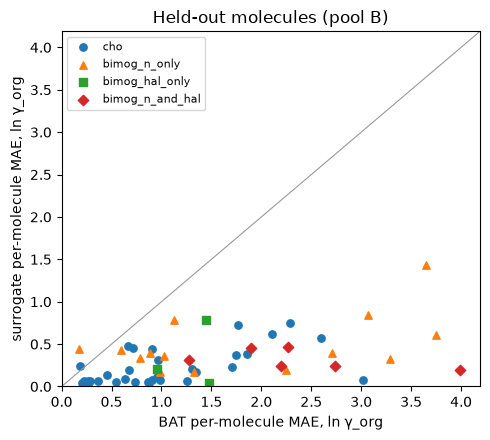

In [10]:
# Per-molecule comparison for CHO test molecules: where does BAT fail relative to the surrogate?
gi = np.where(gen_B)[0]
per = pd.DataFrame({"mol": oi_B[gi], "sur": err_sur[:, 1], "bat": err_bat[gi, 1]}).groupby("mol").mean()
per["name"] = [kept_B[i]["name"] for i in per.index]
per["category"] = [kept_B[i]["category"] for i in per.index]
per["O:C"] = [kept_B[i]["o_to_c"] for i in per.index]
per["M"] = [kept_B[i]["molar_mass_g_mol"] for i in per.index]
cho = per[per.category == "cho"]
print(f"CHO test molecules: surrogate better on {(cho.sur < cho.bat).sum()}/{len(cho)}")
display(cho.sort_values("bat", ascending=False).head(10).round(3))

fig, ax = plt.subplots(figsize=(5, 4.5))
for c, mk in zip(CATS, "o^sD"):
    s = per[per.category == c]
    ax.scatter(s.bat, s.sur, marker=mk, s=28, label=c)
lim = [0, max(per.bat.max(), per.sur.max()) * 1.05]
ax.plot(lim, lim, color="0.6", lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("BAT per-molecule MAE, ln γ_org"); ax.set_ylabel("surrogate per-molecule MAE, ln γ_org")
ax.legend(fontsize=8); ax.set_title("Held-out molecules (pool B)")
plt.tight_layout(); plt.savefig("bat_vs_surrogate.png", dpi=200); plt.show()

## 5) What to carry into the paper

- **Table 1.** Replace the single-run numbers with the seeded mean ± sd from §2, and add the `bimog_hal_only`
  column (with its n). Rewrite Sec. 3.2's claims on synthetic-N augmentation according to the per-seed
  C − B differences. Delete the "global RNG state is not reset" limitation in Sec. 4.1: it no longer applies.
- **Table 2.** Give Model A the ± sd from §3, and note in the caption that every row now has a seed spread.
- **New baseline.** Add BAT to Table 2 (or as a new Table 1 row) with the §4 numbers. In Sec. 3.1, discuss
  what the trained surrogate adds beyond BAT, which uses the same kind of descriptors (O:C, M) and no training.
  This is the paper's answer to "why not just use BAT?". Cite Gorkowski et al. (2019) and Girolami (1994).